# Phase 2 - ML Baselines and Cost-Sensitive Metrics

Notebook này triển khai Phase 2 cho đề tài IEEE-CIS Fraud Detection. Mục tiêu là tạo baseline ML và đánh giá cost-sensitive trên split thời gian 70/15/15 theo `TransactionDT`.

Phạm vi cố định của Phase 2:

- Có approve-all baseline làm mốc chi phí.
- Có Logistic Regression với imbalance handling.
- Có một baseline mạnh hơn: LightGBM/XGBoost nếu có, nếu không dùng Random Forest fallback.
- Tune threshold trên validation, rồi đánh giá test.
- Có thêm Kaggle-inspired XGB Magic-style baseline leakage-safe ở Phase 2.1.
- Không triển khai LLM embedding, table-to-text, hoặc RL trong notebook này.

## 1. Setup and Configuration

Notebook h? tr? ba ch? ?? ch?y qua `RUN_MODE`:

| RUN_MODE | SAMPLE_ROWS | M?c ??ch |
|---|---:|---|
| `"smoke"` | 10,000 | Test nhanh local, kh?ng d?ng ?? k?t lu?n. |
| `"sample_100k"` | 100,000 | B??c ??u cho Colab/RAM 12GB v? so s?nh c?ng b?ng v?i Phase 3. |
| `"sample_200k"` | 200,000 | T?ng d?n sau khi 100k ch?y ?n. |
| `"sample_300k"` | 300,000 | T?ng ti?p n?u RAM/runtime c?n ??. |
| `"full"` | to?n b? | Full IEEE-CIS, ch? ch?y khi RAM ??. |

M?c ??nh hi?n t?i ??t `RUN_MODE = "sample_100k"`. Sau khi 100k ?n, ??i l?n l??t sang `"sample_200k"`, `"sample_300k"`; ch? ??i sang `"full"` khi runtime ?? RAM.


In [2]:
from pathlib import Path
import inspect
import json
import gc
import os
import shutil
import subprocess
import sys
import warnings
import zipfile

import numpy as np
import pandas as pd

try:
    from IPython.display import display
except Exception:
    display = print

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

SEED = 42
np.random.seed(SEED)

# Run modes:
# - "smoke": quick 10k-row local/debug run.
# - "sample_100k": first 100k rows, RAM-safer and matched with Phase 3.
# - "sample_200k"/"sample_300k": gradual larger samples after 100k is stable.
# - "full": all IEEE-CIS train rows. Use only when RAM allows.
RUN_MODE = "sample_100k"
RUN_MODE_SAMPLE_ROWS = {
    "smoke": 10_000,
    "sample_100k": 100_000,
    "sample_200k": 200_000,
    "sample_300k": 300_000,
    "full": None,
}
if RUN_MODE not in RUN_MODE_SAMPLE_ROWS:
    raise ValueError(f"Unsupported RUN_MODE={RUN_MODE!r}. Use one of {list(RUN_MODE_SAMPLE_ROWS)}.")

# Optional manual override for one-off debugging. Leave None for normal RUN_MODE behavior.
MANUAL_SAMPLE_ROWS_OVERRIDE = None
SAMPLE_ROWS = RUN_MODE_SAMPLE_ROWS[RUN_MODE] if MANUAL_SAMPLE_ROWS_OVERRIDE is None else int(MANUAL_SAMPLE_ROWS_OVERRIDE)
RUN_OUTPUT_TAG = RUN_MODE if MANUAL_SAMPLE_ROWS_OVERRIDE is None else f"manual_{SAMPLE_ROWS}_rows"
SAMPLE_ROWS_LABEL = SAMPLE_ROWS if SAMPLE_ROWS is not None else "full"
SPLIT_RATIOS = (0.70, 0.15, 0.15)

RUN_LOGISTIC_BASELINE = True
RUN_STRONG_BASELINE = True
RUN_MAGIC_BASELINE = True

MISSING_THRESHOLD = 0.95
RARE_CATEGORY_MIN_FREQUENCY = 10
N_JOBS = 1 if RUN_MODE.startswith("sample_") else 2  # 1 is safer for 12GB sample runs.

MAGIC_COUNT_COLUMNS = [
    "card1",
    "card2",
    "addr1",
    "P_emaildomain",
    "R_emaildomain",
    "card1_addr1",
]
MAGIC_AMOUNT_GROUP_COLUMNS = ["card1", "card1_addr1"]
MAGIC_GROUP_KEYS = {"card1_addr1": ["card1", "addr1"]}

FEATURE_MODE = "ram_safe"  # "ram_safe" = full rows with curated columns; "all" = every column, high RAM only.

BASE_TRANSACTION_COLUMNS = [
    "TransactionID", "isFraud", "TransactionDT", "TransactionAmt", "ProductCD",
    "card1", "card2", "card3", "card4", "card5", "card6",
    "addr1", "addr2", "dist1", "dist2", "P_emaildomain", "R_emaildomain",
    *[f"C{i}" for i in range(1, 15)],
    *[f"D{i}" for i in range(1, 16)],
    *[f"M{i}" for i in range(1, 10)],
]

# Selected V-columns keep the baseline meaningful without loading all 339 anonymous V features.
RAM_SAFE_V_COLUMNS = [
    "V1", "V3", "V4", "V6", "V8", "V11", "V13", "V14", "V17", "V20",
    "V23", "V26", "V27", "V30", "V36", "V37", "V40", "V44", "V45",
    "V47", "V48", "V54", "V56", "V61", "V62", "V67", "V70", "V76",
    "V78", "V82", "V83", "V86", "V87", "V91", "V96", "V99", "V124",
    "V126", "V127", "V128", "V130", "V131", "V135", "V136", "V138",
    "V139", "V140", "V143", "V147", "V160", "V165", "V169", "V170",
    "V171", "V174", "V175", "V176", "V178", "V180", "V182", "V187",
    "V188", "V189", "V197", "V200", "V201", "V203", "V204", "V207",
    "V209", "V210", "V217", "V220", "V221", "V223", "V224", "V226",
    "V228", "V229", "V234", "V238", "V240", "V242", "V243", "V244",
    "V246", "V250", "V252", "V253", "V257", "V258", "V261", "V264",
    "V266", "V267", "V271", "V274", "V277", "V281", "V282", "V283",
    "V285", "V287", "V291", "V294", "V303", "V306", "V307", "V308",
    "V310", "V312", "V313", "V314", "V315", "V317", "V320",
]

RAM_SAFE_IDENTITY_COLUMNS = [
    "DeviceType", "DeviceInfo",
    *[f"id_{i:02d}" for i in range(12, 39)],
]

COST_CONFIGS = {
    "Cost-A": {"alpha": 0.05, "beta": 1.0},
    "Cost-B": {"alpha": 0.10, "beta": 2.0},
    "Cost-C": {"alpha": 0.20, "beta": 5.0},
}

sns.set_theme(style="whitegrid")

IN_COLAB = "COLAB_RELEASE_TAG" in os.environ
MOUNT_GOOGLE_DRIVE = IN_COLAB

# Optional manual fix. Example:
# PROJECT_ROOT_OVERRIDE = "/content/drive/MyDrive/BaoMatCuoiKy/LLM-Assisted_Cost-Sensitive"
PROJECT_ROOT_OVERRIDE = ""
SEARCH_GOOGLE_DRIVE = IN_COLAB
MAX_SEARCH_DIRS = 4000

if IN_COLAB and MOUNT_GOOGLE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")


def looks_like_project_root(path):
    path = Path(path)
    return (
        (path / "notebooks").exists()
        and (
            (path / "notebooks" / "02_baselines_cost_metrics.ipynb").exists()
            or (path / "requirements.txt").exists()
            or (path / "src").exists()
        )
    )


def walk_for_project_roots(base, max_dirs=MAX_SEARCH_DIRS):
    base = Path(base)
    if not base.exists():
        return []

    matches = []
    visited = 0
    skip_names = {".git", "__pycache__", ".ipynb_checkpoints", "data", "artifacts", "results", "reports"}
    for current, dirs, _files in os.walk(base):
        visited += 1
        dirs[:] = [name for name in dirs if name not in skip_names and not name.startswith(".")]
        current_path = Path(current)
        if looks_like_project_root(current_path):
            matches.append(current_path.resolve())
        if visited >= max_dirs:
            break
    return matches


def find_project_root(start=None):
    candidates = []
    if PROJECT_ROOT_OVERRIDE:
        candidates.append(Path(PROJECT_ROOT_OVERRIDE))

    env_root = os.environ.get("PROJECT_ROOT")
    if env_root:
        candidates.append(Path(env_root))

    start = Path(start or Path.cwd()).resolve()
    candidates.extend([start, *start.parents])

    if IN_COLAB:
        candidates.extend(
            [
                Path("/content/LLM-Assisted_Cost-Sensitive"),
                Path("/content/drive/MyDrive/LLM-Assisted_Cost-Sensitive"),
                Path("/content/drive/MyDrive/BaoMatCuoiKy/LLM-Assisted_Cost-Sensitive"),
            ]
        )

    seen = set()
    for candidate in candidates:
        candidate = candidate.expanduser()
        if not candidate.exists():
            continue
        resolved = candidate.resolve()
        if resolved in seen:
            continue
        seen.add(resolved)
        if looks_like_project_root(resolved):
            return resolved
        if (resolved / "data" / "raw" / "train_transaction.csv").exists():
            return resolved

    search_bases = [Path("/content")]
    if SEARCH_GOOGLE_DRIVE:
        search_bases.append(Path("/content/drive/MyDrive"))

    for base in search_bases:
        matches = walk_for_project_roots(base)
        if matches:
            print("Found candidate project roots:")
            for match in matches[:5]:
                print("-", match)
            return matches[0]

    return start


PROJECT_ROOT = find_project_root()
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

RAW_DIR = PROJECT_ROOT / "data" / "raw"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"

RAW_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

DATA_SOURCE_DIRS = [
    RAW_DIR,
    Path("/content/ieee-fraud-detection"),
    Path("/content/drive/MyDrive/ieee-fraud-detection"),
    Path("/content/drive/MyDrive/Kaggle/ieee-fraud-detection"),
    Path("/content/drive/MyDrive/BaoMatCuoiKy/ieee-fraud-detection"),
    PROJECT_ROOT.parent / "ieee-fraud-detection",
]

KAGGLE_JSON_CANDIDATES = [
    Path("/content/kaggle.json"),
    PROJECT_ROOT / "kaggle.json",
    Path("/content/drive/MyDrive/kaggle.json"),
    Path("/content/drive/MyDrive/BaoMatCuoiKy/kaggle.json"),
]

print(f"Running in Colab: {IN_COLAB}")
print(f"Project root: {PROJECT_ROOT}")
print(f"Raw dir: {RAW_DIR}")
print(f"RUN_MODE={RUN_MODE} | SAMPLE_ROWS={SAMPLE_ROWS_LABEL} | RUN_OUTPUT_TAG={RUN_OUTPUT_TAG} | N_JOBS={N_JOBS}")
print("Phase 2 scope: baseline ML + cost-sensitive evaluation only.")


Mounted at /content/drive
Running in Colab: True
Project root: /content/drive/MyDrive/BaoMatCuoiKy/LLM-Assisted_Cost-Sensitive
Raw dir: /content/drive/MyDrive/BaoMatCuoiKy/LLM-Assisted_Cost-Sensitive/data/raw
RUN_MODE=sample_100k | SAMPLE_ROWS=100000 | RUN_OUTPUT_TAG=sample_100k | N_JOBS=1
Phase 2 scope: baseline ML + cost-sensitive evaluation only.


## 2. Prepare, Load, Join, and Time-Based Split

Notebook kiểm tra `data/raw`, tự copy/unzip dữ liệu IEEE-CIS từ Google Drive hoặc `/content` nếu có, rồi đọc `train_transaction.csv` và `train_identity.csv`. Ở chế độ RAM-safe, notebook vẫn dùng toàn bộ số dòng nhưng chỉ đọc nhóm cột cần cho baseline để tránh quá tải RAM Colab. Sau đó notebook left join bằng `TransactionID` và sort theo `TransactionDT` để tạo split 70/15/15 như Phase 1.


In [3]:
REQUIRED_RAW_FILES = ["train_transaction.csv", "train_identity.csv"]
KAGGLE_COMPETITION = "ieee-fraud-detection"


def missing_raw_files(raw_dir):
    return [name for name in REQUIRED_RAW_FILES if not (raw_dir / name).exists()]


def unzip_archives(raw_dir):
    extracted = []
    for archive_path in raw_dir.glob("*.zip"):
        with zipfile.ZipFile(archive_path) as archive:
            archive.extractall(raw_dir)
        extracted.append(archive_path)
    return extracted


def stage_kaggle_json():
    target = Path.home() / ".kaggle" / "kaggle.json"
    for source in KAGGLE_JSON_CANDIDATES:
        if source.exists():
            target.parent.mkdir(parents=True, exist_ok=True)
            if source.resolve() != target.resolve():
                shutil.copy2(source, target)
            try:
                target.chmod(0o600)
            except OSError:
                pass
            return target
    return None


def has_kaggle_credentials():
    credential_file = stage_kaggle_json()
    env_credentials = bool(os.environ.get("KAGGLE_USERNAME") and os.environ.get("KAGGLE_KEY"))
    return credential_file is not None or env_credentials


def stage_raw_files(raw_dir):
    copied = []
    raw_dir.mkdir(parents=True, exist_ok=True)
    for source_dir in DATA_SOURCE_DIRS:
        source_dir = Path(source_dir)
        if not source_dir.exists():
            continue
        if source_dir.resolve() == raw_dir.resolve():
            continue

        for name in REQUIRED_RAW_FILES:
            source = source_dir / name
            target = raw_dir / name
            if source.exists() and not target.exists():
                shutil.copy2(source, target)
                copied.append(target)

        for source in source_dir.glob("*.zip"):
            target = raw_dir / source.name
            if not target.exists():
                shutil.copy2(source, target)
                copied.append(target)
    return copied


def download_with_kaggle(raw_dir):
    try:
        import kaggle  # noqa: F401
    except Exception:
        print("Package 'kaggle' is missing. Installing it for this Colab session...")
        subprocess.run([sys.executable, "-m", "pip", "install", "kaggle"], check=True)

    command = [
        sys.executable,
        "-m",
        "kaggle",
        "competitions",
        "download",
        "-c",
        KAGGLE_COMPETITION,
        "-p",
        str(raw_dir),
    ]
    subprocess.run(command, check=True)


def prepare_raw_data(raw_dir):
    raw_dir = Path(raw_dir)
    raw_dir.mkdir(parents=True, exist_ok=True)

    copied = stage_raw_files(raw_dir)
    if copied:
        print("Staged raw files:")
        for path in copied:
            print("-", path)

    extracted = unzip_archives(raw_dir)
    if extracted:
        print("Unzipped archives:")
        for path in extracted:
            print("-", path)

    if missing_raw_files(raw_dir) and has_kaggle_credentials():
        print("Kaggle credentials found. Downloading IEEE-CIS Fraud Detection...")
        download_with_kaggle(raw_dir)
        unzip_archives(raw_dir)


def validate_raw_files(raw_dir):
    prepare_raw_data(raw_dir)
    missing = missing_raw_files(raw_dir)
    if missing:
        search_locations = "\n".join(f"- {path}" for path in DATA_SOURCE_DIRS)
        credential_locations = "\n".join(f"- {path}" for path in KAGGLE_JSON_CANDIDATES)
        raise FileNotFoundError(
            "Missing IEEE-CIS raw files in " + str(raw_dir) + ": " + ", ".join(missing) + "\n\n"
            "Colab fix options:\n"
            "1. Put train_transaction.csv and train_identity.csv, or the Kaggle ZIP, in one of these folders:\n"
            f"{search_locations}\n"
            "2. Or put kaggle.json in one of these locations and rerun this cell:\n"
            f"{credential_locations}\n"
            "3. Make sure you accepted the IEEE-CIS Fraud Detection competition rules on Kaggle."
        )


def unique_existing_columns(columns):
    return list(dict.fromkeys(columns))


def desired_transaction_columns():
    if FEATURE_MODE == "all":
        return None
    return unique_existing_columns(BASE_TRANSACTION_COLUMNS + RAM_SAFE_V_COLUMNS)


def desired_identity_columns():
    if FEATURE_MODE == "all":
        return None
    return unique_existing_columns(["TransactionID"] + RAM_SAFE_IDENTITY_COLUMNS)


def read_ieee_csv(path, desired_columns=None, required_columns=None, nrows=None):
    header = pd.read_csv(path, nrows=0).columns.tolist()
    required_columns = required_columns or []

    if FEATURE_MODE == "all":
        usecols = None
        print(f"Reading {path.name}: all {len(header)} columns. This needs a high-RAM runtime.")
    elif FEATURE_MODE == "ram_safe":
        usecols = [col for col in desired_columns if col in header]
        missing_required = [col for col in required_columns if col not in usecols]
        if missing_required:
            raise AssertionError(f"Missing required column(s) in {path.name}: {missing_required}")
        print(f"Reading {path.name}: {len(usecols)}/{len(header)} columns in RAM-safe mode.")
    else:
        raise ValueError("FEATURE_MODE must be 'ram_safe' or 'all'.")

    df = pd.read_csv(path, usecols=usecols, nrows=nrows, low_memory=False)
    return optimize_dtypes(df)


def optimize_dtypes(df):
    for col in df.columns:
        series = df[col]
        if pd.api.types.is_float_dtype(series):
            df[col] = pd.to_numeric(series, downcast="float")
        elif pd.api.types.is_integer_dtype(series):
            df[col] = pd.to_numeric(series, downcast="integer")
        elif pd.api.types.is_object_dtype(series):
            df[col] = series.astype("category")
    return df


def dataframe_memory_mb(df):
    return df.memory_usage(deep=True).sum() / (1024 ** 2)


def load_ieee_data(raw_dir, sample_rows=None):
    validate_raw_files(raw_dir)
    transaction_path = raw_dir / "train_transaction.csv"
    identity_path = raw_dir / "train_identity.csv"

    transaction = read_ieee_csv(
        transaction_path,
        desired_columns=desired_transaction_columns(),
        required_columns=["TransactionID", "isFraud", "TransactionDT", "TransactionAmt"],
        nrows=sample_rows,
    )
    identity = read_ieee_csv(
        identity_path,
        desired_columns=desired_identity_columns(),
        required_columns=["TransactionID"],
        nrows=None,
    )

    transaction_shape = transaction.shape
    identity_shape = identity.shape
    identity_ids = identity["TransactionID"].copy()

    joined = transaction.merge(identity, on="TransactionID", how="left", suffixes=("", "_identity"), copy=False)
    if len(joined) != len(transaction):
        raise AssertionError(
            f"Join row-count mismatch: transaction={len(transaction)}, joined={len(joined)}"
        )
    if "isFraud" not in joined.columns:
        raise AssertionError("Column isFraud is missing after load/join.")
    if "TransactionDT" not in joined.columns:
        raise AssertionError("Column TransactionDT is missing after load/join.")
    if "TransactionAmt" not in joined.columns:
        raise AssertionError("Column TransactionAmt is missing after load/join.")

    joined = optimize_dtypes(joined)
    dataset_summary = make_dataset_summary(transaction_shape, identity_shape, joined, identity_ids)

    del transaction, identity, identity_ids
    gc.collect()
    return joined, dataset_summary


def split_by_transaction_dt(df, ratios=(0.70, 0.15, 0.15)):
    if not np.isclose(sum(ratios), 1.0):
        raise ValueError("Split ratios must sum to 1.0")

    ordered = df.sort_values("TransactionDT", kind="mergesort").reset_index(drop=True)
    n_rows = len(ordered)
    n_train = int(n_rows * ratios[0])
    n_val = int(n_rows * ratios[1])

    train = ordered.iloc[:n_train].copy()
    validation = ordered.iloc[n_train:n_train + n_val].copy()
    test = ordered.iloc[n_train + n_val:].copy()

    train_ids = set(train["TransactionID"].tolist())
    validation_ids = set(validation["TransactionID"].tolist())
    test_ids = set(test["TransactionID"].tolist())
    if train_ids.intersection(validation_ids) or train_ids.intersection(test_ids) or validation_ids.intersection(test_ids):
        raise AssertionError("Split TransactionID values overlap unexpectedly.")

    del ordered, train_ids, validation_ids, test_ids
    gc.collect()
    return {"train": train, "validation": validation, "test": test}


def make_dataset_summary(transaction_shape, identity_shape, joined, identity_ids):
    fraud_count = int(joined["isFraud"].sum())
    legitimate_count = int((joined["isFraud"] == 0).sum())
    identity_matches = int(joined["TransactionID"].isin(identity_ids).sum())
    return pd.DataFrame([
        {"metric": "run_mode", "value": RUN_MODE},
        {"metric": "sample_rows", "value": SAMPLE_ROWS_LABEL},
        {"metric": "run_output_tag", "value": RUN_OUTPUT_TAG},
        {"metric": "feature_mode", "value": FEATURE_MODE},
        {"metric": "transaction_shape_loaded", "value": str(transaction_shape)},
        {"metric": "identity_shape_loaded", "value": str(identity_shape)},
        {"metric": "joined_shape_loaded", "value": str(joined.shape)},
        {"metric": "joined_memory_mb", "value": round(dataframe_memory_mb(joined), 2)},
        {"metric": "fraud_count", "value": fraud_count},
        {"metric": "legitimate_count", "value": legitimate_count},
        {"metric": "fraud_rate", "value": fraud_count / len(joined)},
        {"metric": "identity_coverage", "value": identity_matches / len(joined)},
    ])


def make_split_summary(splits):
    rows = []
    for split_name, split_df in splits.items():
        fraud_count = int(split_df["isFraud"].sum())
        rows.append({
            "split": split_name,
            "rows": len(split_df),
            "fraud_count": fraud_count,
            "legitimate_count": int((split_df["isFraud"] == 0).sum()),
            "fraud_rate": fraud_count / len(split_df),
            "transactiondt_min": int(split_df["TransactionDT"].min()),
            "transactiondt_max": int(split_df["TransactionDT"].max()),
            "memory_mb": round(dataframe_memory_mb(split_df), 2),
        })
    return pd.DataFrame(rows)


joined_df, dataset_summary = load_ieee_data(RAW_DIR, sample_rows=SAMPLE_ROWS)
splits = split_by_transaction_dt(joined_df, ratios=SPLIT_RATIOS)
train_df = splits["train"]
validation_df = splits["validation"]
test_df = splits["test"]
del joined_df, splits
gc.collect()

split_summary = make_split_summary({"train": train_df, "validation": validation_df, "test": test_df})

print("Dataset summary")
display(dataset_summary)
print("Split summary")
display(split_summary)

# Save lightweight audit tables generated by this notebook run.
dataset_summary.to_csv(RESULTS_DIR / "phase2_dataset_summary.csv", index=False)
split_summary.to_csv(RESULTS_DIR / "phase2_split_summary.csv", index=False)
dataset_summary.to_csv(RESULTS_DIR / f"phase2_dataset_summary_{RUN_OUTPUT_TAG}.csv", index=False)
split_summary.to_csv(RESULTS_DIR / f"phase2_split_summary_{RUN_OUTPUT_TAG}.csv", index=False)


Reading train_transaction.csv: 171/394 columns in RAM-safe mode.
Reading train_identity.csv: 30/41 columns in RAM-safe mode.
Dataset summary


,metric,value
0,run_mode,sample_100k
1,sample_rows,100000
2,run_output_tag,sample_100k
3,feature_mode,ram_safe
4,transaction_shape_loaded,"(100000, 171)"
5,identity_shape_loaded,"(144233, 30)"
6,joined_shape_loaded,"(100000, 200)"
7,joined_memory_mb,67.47
8,fraud_count,2561
9,legitimate_count,97439


Split summary


,split,rows,fraud_count,legitimate_count,fraud_rate,transactiondt_min,transactiondt_max,memory_mb
0,train,70000,1879,68121,0.026843,86400,1564844,47.30
1,validation,15000,377,14623,0.025133,1564850,1804023,10.32
2,test,15000,305,14695,0.020333,1804027,2006364,10.32


## 3. Feature and Leakage Policy

Các bước fit như imputer, encoder, scaler và threshold tuning chỉ dùng train/validation đúng vai trò. `TransactionID` và `isFraud` không bao giờ vào feature model. `TransactionAmt` vẫn được giữ để vừa làm feature giao dịch, vừa tính chi phí FN/FP.

In [4]:
def add_time_features(df):
    out = df.copy()
    seconds_per_day = 24 * 60 * 60
    out["TransactionDT_day"] = np.floor(out["TransactionDT"] / seconds_per_day).astype("int32")
    out["TransactionDT_hour"] = np.floor((out["TransactionDT"] % seconds_per_day) / 3600).astype("int16")
    out["TransactionDT_weekday_proxy"] = (out["TransactionDT_day"] % 7).astype("int16")
    return optimize_dtypes(out)


def select_feature_columns(train_features, missing_threshold=0.95):
    excluded = {"TransactionID", "isFraud", "TransactionDT"}
    candidates = [col for col in train_features.columns if col not in excluded]
    missing_ratio = train_features[candidates].isna().mean()
    keep = missing_ratio[missing_ratio <= missing_threshold].index.tolist()

    # TransactionAmt is required for cost-sensitive fraud modeling and should remain visible.
    if "TransactionAmt" not in keep and "TransactionAmt" in train_features.columns:
        keep.append("TransactionAmt")

    keep_set = set(keep)
    return [col for col in train_features.columns if col in keep_set]


train_with_time = add_time_features(train_df)
feature_columns = select_feature_columns(train_with_time, missing_threshold=MISSING_THRESHOLD)

train_X = train_with_time.loc[:, feature_columns].copy()
validation_X = add_time_features(validation_df).loc[:, feature_columns].copy()
test_X = add_time_features(test_df).loc[:, feature_columns].copy()
del train_with_time
gc.collect()

y_train = train_df["isFraud"].astype(int).to_numpy()
y_validation = validation_df["isFraud"].astype(int).to_numpy()
y_test = test_df["isFraud"].astype(int).to_numpy()

amount_train = train_df["TransactionAmt"].fillna(0).astype(float).to_numpy()
amount_validation = validation_df["TransactionAmt"].fillna(0).astype(float).to_numpy()
amount_test = test_df["TransactionAmt"].fillna(0).astype(float).to_numpy()

numeric_features = [col for col in feature_columns if pd.api.types.is_numeric_dtype(train_X[col])]
categorical_features = [col for col in feature_columns if col not in numeric_features]

feature_policy = pd.DataFrame([
    {"item": "run_mode", "value": RUN_MODE},
    {"item": "sample_rows", "value": SAMPLE_ROWS_LABEL},
    {"item": "run_output_tag", "value": RUN_OUTPUT_TAG},
    {"item": "feature_mode", "value": FEATURE_MODE},
    {"item": "selected_features", "value": len(feature_columns)},
    {"item": "numeric_features", "value": len(numeric_features)},
    {"item": "categorical_features", "value": len(categorical_features)},
    {"item": "missing_threshold_train_only", "value": MISSING_THRESHOLD},
    {"item": "excluded_from_features", "value": "TransactionID, isFraud, raw TransactionDT"},
    {"item": "time_features", "value": "TransactionDT_day, TransactionDT_hour, TransactionDT_weekday_proxy"},
    {"item": "train_X_memory_mb", "value": round(dataframe_memory_mb(train_X), 2)},
])

display(feature_policy)
feature_policy.to_csv(RESULTS_DIR / "phase2_feature_policy.csv", index=False)
feature_policy.to_csv(RESULTS_DIR / f"phase2_feature_policy_{RUN_OUTPUT_TAG}.csv", index=False)

if len(np.unique(y_train)) < 2:
    raise ValueError("Train split has only one class. Increase SAMPLE_ROWS or use the full dataset.")


,item,value
0,run_mode,sample_100k
1,sample_rows,100000
2,run_output_tag,sample_100k
3,feature_mode,ram_safe
4,selected_features,193
5,numeric_features,164
6,categorical_features,29
7,missing_threshold_train_only,0.95
8,excluded_from_features,"TransactionID, isFraud, raw TransactionDT"
9,time_features,"TransactionDT_day, TransactionDT_hour, Transac..."


## 3.1. Kaggle-Inspired Magic Features

Phase 2.1 thêm một nhóm feature lấy cảm hứng từ các IEEE-CIS Kaggle solutions, nhưng chỉ dùng thống kê fit trên train rồi map sang validation/test. Không dùng Kaggle test files, không dùng label, không dùng model score, và không tính aggregation trên toàn bộ dataset trước split.

In [5]:
def series_as_key(df, col):
    if col not in df.columns:
        return pd.Series("missing", index=df.index, dtype="string")
    return df[col].astype("string").fillna("missing")


def make_group_key_series(df, cols):
    parts = [series_as_key(df, col) for col in cols]
    if not parts:
        return pd.Series("missing", index=df.index, dtype="string")
    key = parts[0]
    for part in parts[1:]:
        key = key.str.cat(part, sep="_")
    return key.fillna("missing")


def add_magic_base_columns(df):
    needed_cols = ["TransactionAmt", *MAGIC_COUNT_COLUMNS, *MAGIC_AMOUNT_GROUP_COLUMNS]
    for cols in MAGIC_GROUP_KEYS.values():
        needed_cols.extend(cols)
    needed_cols = [col for col in unique_existing_columns(needed_cols) if col in df.columns]
    out = df.loc[:, needed_cols].copy()
    for output_col, cols in MAGIC_GROUP_KEYS.items():
        out[output_col] = make_group_key_series(out, cols)
    amount = pd.to_numeric(out.get("TransactionAmt", pd.Series(0, index=out.index)), errors="coerce").fillna(0.0)
    out["magic_amount_cents"] = (amount - np.floor(amount)).astype("float32")
    return optimize_dtypes(out)


def fit_count_encoding(train_with_keys, columns):
    maps = {}
    n_train = max(1, len(train_with_keys))
    for col in columns:
        if col not in train_with_keys.columns:
            continue
        keys = series_as_key(train_with_keys, col)
        counts = keys.value_counts(dropna=False).astype("float32")
        freqs = (counts / n_train).astype("float32")
        maps[col] = {"counts": counts, "freqs": freqs}
    return maps


def apply_count_encoding(df_with_keys, count_maps):
    features = pd.DataFrame(index=df_with_keys.index)
    for col, payload in count_maps.items():
        keys = series_as_key(df_with_keys, col)
        safe_col = col.replace(".", "_").replace(" ", "_")
        features[f"magic_{safe_col}_count_train"] = keys.map(payload["counts"]).fillna(0).astype("float32")
        features[f"magic_{safe_col}_freq_train"] = keys.map(payload["freqs"]).fillna(0).astype("float32")
    return features


def fit_group_amount_stats(train_with_keys, group_cols):
    amount = pd.to_numeric(train_with_keys["TransactionAmt"], errors="coerce").fillna(0.0)
    global_mean = float(amount.mean()) if len(amount) else 0.0
    global_std = float(amount.std(ddof=0)) if len(amount) else 0.0
    maps = {}
    for col in group_cols:
        if col not in train_with_keys.columns:
            continue
        grouped = amount.groupby(series_as_key(train_with_keys, col), dropna=False).agg(["count", "mean", "std"])
        grouped["std"] = grouped["std"].fillna(0.0)
        maps[col] = {
            "stats": grouped.astype("float32"),
            "global_mean": global_mean,
            "global_std": global_std,
        }
    return maps


def apply_group_amount_stats(df_with_keys, stats_maps):
    features = pd.DataFrame(index=df_with_keys.index)
    for col, payload in stats_maps.items():
        keys = series_as_key(df_with_keys, col)
        stats = payload["stats"]
        safe_col = col.replace(".", "_").replace(" ", "_")
        features[f"magic_{safe_col}_TransactionAmt_count_train"] = keys.map(stats["count"]).fillna(0).astype("float32")
        features[f"magic_{safe_col}_TransactionAmt_mean_train"] = keys.map(stats["mean"]).fillna(payload["global_mean"]).astype("float32")
        features[f"magic_{safe_col}_TransactionAmt_std_train"] = keys.map(stats["std"]).fillna(payload["global_std"]).astype("float32")
    return features


def add_magic_features_train_valid_test(train, validation, test):
    train_with_keys = add_magic_base_columns(train)
    validation_with_keys = add_magic_base_columns(validation)
    test_with_keys = add_magic_base_columns(test)

    count_maps = fit_count_encoding(train_with_keys, MAGIC_COUNT_COLUMNS)
    stats_maps = fit_group_amount_stats(train_with_keys, MAGIC_AMOUNT_GROUP_COLUMNS)

    def transform(df_with_keys):
        parts = [
            pd.DataFrame({"magic_amount_cents": df_with_keys["magic_amount_cents"].astype("float32")}, index=df_with_keys.index),
            apply_count_encoding(df_with_keys, count_maps),
            apply_group_amount_stats(df_with_keys, stats_maps),
        ]
        return pd.concat(parts, axis=1)

    magic_train = transform(train_with_keys)
    magic_validation = transform(validation_with_keys)
    magic_test = transform(test_with_keys)

    forbidden = {"isFraud", "TransactionID"}
    leaked = [col for col in magic_train.columns if col in forbidden or "score" in col.lower()]
    if leaked:
        raise AssertionError(f"Forbidden magic feature(s): {leaked}")
    if not all(pd.api.types.is_numeric_dtype(magic_train[col]) for col in magic_train.columns):
        raise AssertionError("All magic features must be numeric.")

    audit_rows = []
    for col in magic_train.columns:
        if col == "magic_amount_cents":
            source = "TransactionAmt fractional component"
        elif "_TransactionAmt_" in col:
            source = "train-only TransactionAmt group statistics"
        elif "_count_train" in col or "_freq_train" in col:
            source = "train-only count/frequency encoding"
        else:
            source = "train-only magic feature"
        audit_rows.append({
            "feature": col,
            "source": source,
            "fit_policy": "fit on train split only, map to validation/test",
            "dtype": str(magic_train[col].dtype),
        })
    audit = pd.DataFrame(audit_rows)
    return magic_train, magic_validation, magic_test, audit


if RUN_MAGIC_BASELINE:
    magic_train_features, magic_validation_features, magic_test_features, magic_feature_policy = add_magic_features_train_valid_test(
        train_df, validation_df, test_df
    )
    magic_feature_names = magic_train_features.columns.tolist()
    magic_train_X = pd.concat([train_X.reset_index(drop=True), magic_train_features.reset_index(drop=True)], axis=1)
    magic_validation_X = pd.concat([validation_X.reset_index(drop=True), magic_validation_features.reset_index(drop=True)], axis=1)
    magic_test_X = pd.concat([test_X.reset_index(drop=True), magic_test_features.reset_index(drop=True)], axis=1)
    magic_numeric_features = numeric_features + magic_feature_names
    magic_categorical_features = categorical_features
    magic_feature_policy.to_csv(RESULTS_DIR / "magic_feature_policy.csv", index=False)
    print("Magic feature policy")
    display(magic_feature_policy)
else:
    magic_feature_names = []
    magic_train_X = train_X
    magic_validation_X = validation_X
    magic_test_X = test_X
    magic_numeric_features = numeric_features
    magic_categorical_features = categorical_features
    magic_feature_policy = pd.DataFrame()


Magic feature policy


,feature,source,fit_policy,dtype
0,magic_amount_cents,TransactionAmt fractional component,"fit on train split only, map to validation/test",float32
1,magic_card1_count_train,train-only count/frequency encoding,"fit on train split only, map to validation/test",float32
2,magic_card1_freq_train,train-only count/frequency encoding,"fit on train split only, map to validation/test",float32
3,magic_card2_count_train,train-only count/frequency encoding,"fit on train split only, map to validation/test",float32
4,magic_card2_freq_train,train-only count/frequency encoding,"fit on train split only, map to validation/test",float32
5,magic_addr1_count_train,train-only count/frequency encoding,"fit on train split only, map to validation/test",float32
6,magic_addr1_freq_train,train-only count/frequency encoding,"fit on train split only, map to validation/test",float32
7,magic_P_emaildomain_count_train,train-only count/frequency encoding,"fit on train split only, map to validation/test",float32
8,magic_P_emaildomain_freq_train,train-only count/frequency encoding,"fit on train split only, map to validation/test",float32
9,magic_R_emaildomain_count_train,train-only count/frequency encoding,"fit on train split only, map to validation/test",float32


## 4. Preprocessing Pipelines

Logistic Regression dùng sparse one-hot để xử lý categorical features. Baseline tree dùng ordinal encoding để tránh tạo ma trận one-hot rất lớn.

In [6]:
def make_simple_imputer(strategy, fill_value=None):
    kwargs = {"strategy": strategy}
    if fill_value is not None:
        kwargs["fill_value"] = fill_value
    if "keep_empty_features" in inspect.signature(SimpleImputer).parameters:
        kwargs["keep_empty_features"] = True
    return SimpleImputer(**kwargs)


def make_one_hot_encoder(min_frequency=10):
    kwargs = {"handle_unknown": "ignore"}
    signature = inspect.signature(OneHotEncoder).parameters
    if "min_frequency" in signature:
        kwargs["min_frequency"] = min_frequency
    if "sparse_output" in signature:
        kwargs["sparse_output"] = True
    else:
        kwargs["sparse"] = True
    return OneHotEncoder(**kwargs)


def make_ordinal_encoder():
    kwargs = {"handle_unknown": "use_encoded_value", "unknown_value": -1}
    signature = inspect.signature(OrdinalEncoder).parameters
    if "encoded_missing_value" in signature:
        kwargs["encoded_missing_value"] = -1
    return OrdinalEncoder(**kwargs)


def build_logistic_preprocessor():
    transformers = []
    if numeric_features:
        transformers.append((
            "num",
            Pipeline([
                ("imputer", make_simple_imputer("median")),
                ("scaler", StandardScaler(with_mean=False)),
            ]),
            numeric_features,
        ))
    if categorical_features:
        transformers.append((
            "cat",
            Pipeline([
                ("imputer", make_simple_imputer("constant", fill_value="missing")),
                ("onehot", make_one_hot_encoder(RARE_CATEGORY_MIN_FREQUENCY)),
            ]),
            categorical_features,
        ))
    return ColumnTransformer(transformers=transformers, remainder="drop", sparse_threshold=0.3)


def build_tree_preprocessor(numeric_cols=None, categorical_cols=None):
    numeric_cols = numeric_features if numeric_cols is None else numeric_cols
    categorical_cols = categorical_features if categorical_cols is None else categorical_cols
    transformers = []
    if numeric_cols:
        transformers.append((
            "num",
            Pipeline([("imputer", make_simple_imputer("median"))]),
            numeric_cols,
        ))
    if categorical_cols:
        transformers.append((
            "cat",
            Pipeline([
                ("imputer", make_simple_imputer("constant", fill_value="missing")),
                ("ordinal", make_ordinal_encoder()),
            ]),
            categorical_cols,
        ))
    return ColumnTransformer(transformers=transformers, remainder="drop", sparse_threshold=0.0)


## 5. Cost-Sensitive Metrics

Action convention: `0 = approve transaction`, `1 = flag/block transaction`.

Cost function:

`FN Cost = sum(TransactionAmt * beta)` for fraud transactions predicted approve.
`FP Cost = sum(TransactionAmt * alpha)` for legitimate transactions predicted flag/block.
`Total Cost = FN Cost + FP Cost`.

In [7]:
def safe_average_precision(y_true, scores):
    if len(np.unique(y_true)) < 2:
        return np.nan
    return float(average_precision_score(y_true, scores))


def safe_roc_auc(y_true, scores):
    if len(np.unique(y_true)) < 2:
        return np.nan
    return float(roc_auc_score(y_true, scores))


def compute_costs(y_true, y_pred, amount, alpha, beta):
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)
    amount = np.asarray(amount, dtype=float)
    amount = np.nan_to_num(amount, nan=0.0, posinf=0.0, neginf=0.0)
    amount = np.clip(amount, 0.0, None)

    fn_mask = (y_true == 1) & (y_pred == 0)
    fp_mask = (y_true == 0) & (y_pred == 1)
    fn_cost = float(np.sum(amount[fn_mask] * beta))
    fp_cost = float(np.sum(amount[fp_mask] * alpha))
    return {
        "fn_cost": fn_cost,
        "fp_cost": fp_cost,
        "total_cost": fn_cost + fp_cost,
    }


def approve_all_cost(y_true, amount, beta):
    y_true = np.asarray(y_true).astype(int)
    amount = np.asarray(amount, dtype=float)
    amount = np.nan_to_num(amount, nan=0.0, posinf=0.0, neginf=0.0)
    amount = np.clip(amount, 0.0, None)
    return float(np.sum(amount[y_true == 1] * beta))


def threshold_grid(scores):
    scores = np.asarray(scores, dtype=float)
    linear = np.linspace(0.0, 1.0, 101)
    quantiles = np.quantile(scores, np.linspace(0.0, 1.0, 101)) if len(scores) else np.array([])
    return np.unique(np.clip(np.concatenate([linear, quantiles]), 0.0, 1.0))


def evaluate_thresholded_predictions(
    model_name,
    split_name,
    cost_config_name,
    y_true,
    scores,
    y_pred,
    amount,
    threshold,
    alpha,
    beta,
):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    costs = compute_costs(y_true, y_pred, amount, alpha=alpha, beta=beta)
    reference_cost = approve_all_cost(y_true, amount, beta=beta)
    cost_saving = reference_cost - costs["total_cost"]
    cost_saving_pct = cost_saving / reference_cost if reference_cost > 0 else np.nan

    return {
        "model": model_name,
        "split": split_name,
        "cost_config": cost_config_name,
        "alpha": alpha,
        "beta": beta,
        "threshold": threshold,
        "pr_auc": safe_average_precision(y_true, scores),
        "roc_auc": safe_roc_auc(y_true, scores),
        "recall_fraud": float(recall_score(y_true, y_pred, zero_division=0)),
        "precision_fraud": float(precision_score(y_true, y_pred, zero_division=0)),
        "f1_fraud": float(f1_score(y_true, y_pred, zero_division=0)),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "fn_cost": costs["fn_cost"],
        "fp_cost": costs["fp_cost"],
        "total_cost": costs["total_cost"],
        "approve_all_cost": reference_cost,
        "cost_saving_vs_approve_all": cost_saving,
        "cost_saving_pct_vs_approve_all": cost_saving_pct,
    }


def tune_threshold_on_validation(model_name, y_true, scores, amount, cost_config_name, alpha, beta):
    rows = []
    for threshold in threshold_grid(scores):
        y_pred = (scores >= threshold).astype(int)
        evaluated = evaluate_thresholded_predictions(
            model_name=model_name,
            split_name="validation",
            cost_config_name=cost_config_name,
            y_true=y_true,
            scores=scores,
            y_pred=y_pred,
            amount=amount,
            threshold=float(threshold),
            alpha=alpha,
            beta=beta,
        )
        rows.append(evaluated)
    curve = pd.DataFrame(rows)
    selected = curve.sort_values(
        ["total_cost", "fn_cost", "fp_cost", "threshold"],
        ascending=[True, True, True, True],
    ).iloc[0].to_dict()
    return selected, curve

## 6. Approve-All Baseline

Approve-all luôn dự đoán `0 = approve`. Đây là mốc so sánh chi phí: tất cả fraud bị bỏ sót sẽ tạo FN cost, nhưng không có FP cost.

In [8]:
model_scores = {
    "approve_all": {
        "validation": np.zeros_like(y_validation, dtype=float),
        "test": np.zeros_like(y_test, dtype=float),
        "description": "Fixed policy: approve every transaction",
    }
}

print("Approve-all baseline registered as cost reference.")

Approve-all baseline registered as cost reference.


## 7. Train Logistic Regression and Stronger Baseline

Logistic Regression là baseline bắt buộc. Baseline mạnh hơn ưu tiên LightGBM/XGBoost nếu môi trường có sẵn; nếu không, dùng Random Forest fallback để notebook vẫn chạy được trên local/Colab cơ bản.

In [9]:
def predict_positive_probability(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, "decision_function"):
        raw = model.decision_function(X)
        return 1.0 / (1.0 + np.exp(-raw))
    raise AttributeError("Model does not expose predict_proba or decision_function.")


trained_models = {}

if RUN_LOGISTIC_BASELINE:
    logistic_model = Pipeline([
        ("preprocess", build_logistic_preprocessor()),
        ("model", LogisticRegression(
            class_weight="balanced",
            max_iter=300,
            solver="saga",
            n_jobs=N_JOBS,
            random_state=SEED,
        )),
    ])
    print("Training Logistic Regression with class_weight='balanced'...")
    logistic_model.fit(train_X, y_train)
    trained_models["logistic_regression_balanced"] = logistic_model
    model_scores["logistic_regression_balanced"] = {
        "validation": predict_positive_probability(logistic_model, validation_X),
        "test": predict_positive_probability(logistic_model, test_X),
        "description": "Logistic Regression + class_weight balanced + sparse one-hot",
    }
    print("Logistic Regression done.")


def build_strong_baseline():
    try:
        from lightgbm import LGBMClassifier
        model = LGBMClassifier(
            n_estimators=300 if SAMPLE_ROWS is None else 120,
            learning_rate=0.05,
            num_leaves=31,
            class_weight="balanced",
            random_state=SEED,
            n_jobs=N_JOBS,
        )
        return "lightgbm_balanced", model
    except Exception:
        pass

    try:
        from xgboost import XGBClassifier
        pos = max(1, int(np.sum(y_train == 1)))
        neg = max(1, int(np.sum(y_train == 0)))
        model = XGBClassifier(
            n_estimators=300 if SAMPLE_ROWS is None else 120,
            max_depth=6,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric="aucpr",
            tree_method="hist",
            random_state=SEED,
            n_jobs=N_JOBS,
            scale_pos_weight=neg / pos,
        )
        return "xgboost_scale_pos_weight", model
    except Exception:
        pass

    rf_kwargs = {
        "n_estimators": 120 if SAMPLE_ROWS is None else 80,
        "max_depth": 14 if SAMPLE_ROWS is None else 10,
        "min_samples_leaf": 10,
        "class_weight": "balanced_subsample",
        "random_state": SEED,
        "n_jobs": N_JOBS,
    }
    if "max_samples" in inspect.signature(RandomForestClassifier).parameters:
        rf_kwargs["max_samples"] = 0.60 if SAMPLE_ROWS is None else 0.80
    return "random_forest_balanced", RandomForestClassifier(**rf_kwargs)


if RUN_STRONG_BASELINE:
    strong_name, strong_estimator = build_strong_baseline()
    strong_model = Pipeline([
        ("preprocess", build_tree_preprocessor()),
        ("model", strong_estimator),
    ])
    print(f"Training stronger baseline: {strong_name}...")
    strong_model.fit(train_X, y_train)
    trained_models[strong_name] = strong_model
    model_scores[strong_name] = {
        "validation": predict_positive_probability(strong_model, validation_X),
        "test": predict_positive_probability(strong_model, test_X),
        "description": "Strong baseline with memory-aware tree preprocessing",
    }
    print(f"{strong_name} done.")


def build_magic_baseline():
    try:
        from xgboost import XGBClassifier
        pos = max(1, int(np.sum(y_train == 1)))
        neg = max(1, int(np.sum(y_train == 0)))
        model = XGBClassifier(
            n_estimators=400 if SAMPLE_ROWS is None else 140,
            max_depth=6,
            learning_rate=0.04,
            subsample=0.85,
            colsample_bytree=0.85,
            eval_metric="aucpr",
            tree_method="hist",
            random_state=SEED,
            n_jobs=N_JOBS,
            scale_pos_weight=neg / pos,
        )
        return "xgboost_magic_style", model
    except Exception as exc:
        print(f"XGBoost magic-style baseline unavailable: {exc}")

    try:
        from lightgbm import LGBMClassifier
        model = LGBMClassifier(
            n_estimators=400 if SAMPLE_ROWS is None else 140,
            learning_rate=0.04,
            num_leaves=48,
            class_weight="balanced",
            random_state=SEED,
            n_jobs=N_JOBS,
        )
        return "lightgbm_magic_style", model
    except Exception as exc:
        print(f"LightGBM magic-style baseline unavailable: {exc}")

    return None, None


if RUN_MAGIC_BASELINE:
    magic_name, magic_estimator = build_magic_baseline()
    if magic_name is None:
        print("Skipping magic-style baseline because neither XGBoost nor LightGBM is available.")
    else:
        magic_model = Pipeline([
            ("preprocess", build_tree_preprocessor(magic_numeric_features, magic_categorical_features)),
            ("model", magic_estimator),
        ])
        print(f"Training Kaggle-inspired magic baseline: {magic_name}...")
        magic_model.fit(magic_train_X, y_train)
        trained_models[magic_name] = magic_model
        model_scores[magic_name] = {
            "validation": predict_positive_probability(magic_model, magic_validation_X),
            "test": predict_positive_probability(magic_model, magic_test_X),
            "description": "Kaggle-inspired train-only count/group aggregation features",
        }
        print(f"{magic_name} done.")

model_inventory = pd.DataFrame([
    {"model": name, "description": payload["description"]}
    for name, payload in model_scores.items()
])
display(model_inventory)

Training Logistic Regression with class_weight='balanced'...
Logistic Regression done.
Training stronger baseline: lightgbm_balanced...
[LightGBM] [Info] Number of positive: 1879, number of negative: 68121
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.117754 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 18386
[LightGBM] [Info] Number of data points in the train set: 70000, number of used features: 192
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
lightgbm_balanced done.
Training Kaggle-inspired magic baseline: xgboost_magic_style...
xgboost_magic_style done.


,model,description
0,approve_all,Fixed policy: approve every transaction
1,logistic_regression_balanced,Logistic Regression + class_weight balanced + ...
2,lightgbm_balanced,Strong baseline with memory-aware tree preproc...
3,xgboost_magic_style,Kaggle-inspired train-only count/group aggrega...


## 8. Validation Threshold Tuning and Test Evaluation

Mỗi model có score xác suất fraud. Threshold được chọn trên validation để minimize `Total Cost` cho từng cấu hình `alpha/beta`, sau đó threshold đó mới được áp dụng lên test.

In [10]:
metrics_rows = []
selected_threshold_rows = []
threshold_curve_rows = []

for cost_config_name, cfg in COST_CONFIGS.items():
    alpha = cfg["alpha"]
    beta = cfg["beta"]

    # Fixed approve-all policy.
    for split_name, y_true, scores, amount in [
        ("validation", y_validation, model_scores["approve_all"]["validation"], amount_validation),
        ("test", y_test, model_scores["approve_all"]["test"], amount_test),
    ]:
        y_pred = np.zeros_like(y_true, dtype=int)
        metrics_rows.append(evaluate_thresholded_predictions(
            model_name="approve_all",
            split_name=split_name,
            cost_config_name=cost_config_name,
            y_true=y_true,
            scores=scores,
            y_pred=y_pred,
            amount=amount,
            threshold=np.nan,
            alpha=alpha,
            beta=beta,
        ))

    # Trained baselines: tune on validation, apply to validation/test for reporting.
    for model_name, payload in model_scores.items():
        if model_name == "approve_all":
            continue

        selected, curve = tune_threshold_on_validation(
            model_name=model_name,
            y_true=y_validation,
            scores=payload["validation"],
            amount=amount_validation,
            cost_config_name=cost_config_name,
            alpha=alpha,
            beta=beta,
        )
        selected_threshold = float(selected["threshold"])
        selected_threshold_rows.append(selected)
        threshold_curve_rows.append(curve)

        for split_name, y_true, scores, amount in [
            ("validation", y_validation, payload["validation"], amount_validation),
            ("test", y_test, payload["test"], amount_test),
        ]:
            y_pred = (scores >= selected_threshold).astype(int)
            metrics_rows.append(evaluate_thresholded_predictions(
                model_name=model_name,
                split_name=split_name,
                cost_config_name=cost_config_name,
                y_true=y_true,
                scores=scores,
                y_pred=y_pred,
                amount=amount,
                threshold=selected_threshold,
                alpha=alpha,
                beta=beta,
            ))

def add_run_scope(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty:
        return df
    out = df.copy()
    out["run_mode"] = RUN_MODE
    out["sample_rows"] = SAMPLE_ROWS_LABEL
    ordered = ["run_mode", "sample_rows"] + [c for c in out.columns if c not in {"run_mode", "sample_rows"}]
    return out[ordered]


metrics_df = add_run_scope(pd.DataFrame(metrics_rows))
selected_thresholds_df = add_run_scope(pd.DataFrame(selected_threshold_rows))
threshold_curve_df = add_run_scope(
    pd.concat(threshold_curve_rows, ignore_index=True) if threshold_curve_rows else pd.DataFrame()
)
confusion_matrices_df = metrics_df[[
    "run_mode", "sample_rows", "model", "split", "cost_config", "threshold", "tn", "fp", "fn", "tp"
]].copy()



def build_baseline_scores_table():
    split_frames = {
        "validation": validation_df,
        "test": test_df,
    }
    split_labels = {
        "validation": y_validation,
        "test": y_test,
    }
    split_amounts = {
        "validation": amount_validation,
        "test": amount_test,
    }

    rows = []
    for model_name, payload in model_scores.items():
        for split_name in ["validation", "test"]:
            if split_name not in payload:
                continue
            scores = np.asarray(payload[split_name], dtype=float)
            frame = split_frames[split_name]
            if len(scores) != len(frame):
                raise ValueError(
                    f"Score length mismatch for {model_name}/{split_name}: "
                    f"scores={len(scores)} rows={len(frame)}"
                )
            rows.append(pd.DataFrame({
                "run_mode": RUN_MODE,
                "sample_rows": SAMPLE_ROWS_LABEL,
                "run_output_tag": RUN_OUTPUT_TAG,
                "split": split_name,
                "TransactionID": frame["TransactionID"].to_numpy(),
                "isFraud": split_labels[split_name],
                "TransactionAmt": split_amounts[split_name],
                "model": model_name,
                "score": scores.astype(float),
            }))

    if not rows:
        return pd.DataFrame(columns=[
            "run_mode", "sample_rows", "run_output_tag", "split", "TransactionID",
            "isFraud", "TransactionAmt", "model", "score"
        ])
    return pd.concat(rows, ignore_index=True)


baseline_scores_df = build_baseline_scores_table()

metrics_df.to_csv(RESULTS_DIR / "baseline_metrics.csv", index=False)
selected_thresholds_df.to_csv(RESULTS_DIR / "threshold_tuning.csv", index=False)
threshold_curve_df.to_csv(RESULTS_DIR / "threshold_curve_validation.csv", index=False)
confusion_matrices_df.to_csv(RESULTS_DIR / "confusion_matrices.csv", index=False)
baseline_scores_df.to_csv(RESULTS_DIR / "baseline_scores.csv", index=False)

metrics_df.to_csv(RESULTS_DIR / f"baseline_metrics_{RUN_OUTPUT_TAG}.csv", index=False)
selected_thresholds_df.to_csv(RESULTS_DIR / f"threshold_tuning_{RUN_OUTPUT_TAG}.csv", index=False)
threshold_curve_df.to_csv(RESULTS_DIR / f"threshold_curve_validation_{RUN_OUTPUT_TAG}.csv", index=False)
confusion_matrices_df.to_csv(RESULTS_DIR / f"confusion_matrices_{RUN_OUTPUT_TAG}.csv", index=False)
baseline_scores_df.to_csv(RESULTS_DIR / f"baseline_scores_{RUN_OUTPUT_TAG}.csv", index=False)

phase2_run_metadata = {
    "phase": 2,
    "run_mode": RUN_MODE,
    "sample_rows": SAMPLE_ROWS_LABEL,
    "run_output_tag": RUN_OUTPUT_TAG,
    "feature_mode": FEATURE_MODE,
    "split_ratios": list(SPLIT_RATIOS),
    "split_rows": {str(row["split"]): int(row["rows"]) for _, row in split_summary.iterrows()},
    "models": sorted(model_scores.keys()),
    "cost_configs": COST_CONFIGS,
    "outputs": {
        "baseline_metrics": str((RESULTS_DIR / "baseline_metrics.csv").relative_to(PROJECT_ROOT)),
        "baseline_metrics_tagged": str((RESULTS_DIR / f"baseline_metrics_{RUN_OUTPUT_TAG}.csv").relative_to(PROJECT_ROOT)),
        "threshold_tuning": str((RESULTS_DIR / "threshold_tuning.csv").relative_to(PROJECT_ROOT)),
        "threshold_tuning_tagged": str((RESULTS_DIR / f"threshold_tuning_{RUN_OUTPUT_TAG}.csv").relative_to(PROJECT_ROOT)),
        "confusion_matrices": str((RESULTS_DIR / "confusion_matrices.csv").relative_to(PROJECT_ROOT)),
        "confusion_matrices_tagged": str((RESULTS_DIR / f"confusion_matrices_{RUN_OUTPUT_TAG}.csv").relative_to(PROJECT_ROOT)),
        "baseline_scores": str((RESULTS_DIR / "baseline_scores.csv").relative_to(PROJECT_ROOT)),
        "baseline_scores_tagged": str((RESULTS_DIR / f"baseline_scores_{RUN_OUTPUT_TAG}.csv").relative_to(PROJECT_ROOT)),
    },
}
for metadata_path in [
    RESULTS_DIR / "phase2_run_metadata.json",
    RESULTS_DIR / f"phase2_run_metadata_{RUN_OUTPUT_TAG}.json",
]:
    with open(metadata_path, "w", encoding="utf-8") as f:
        json.dump(phase2_run_metadata, f, ensure_ascii=False, indent=2)

print("Selected validation thresholds")
display(selected_thresholds_df[[
    "model", "cost_config", "alpha", "beta", "threshold",
    "recall_fraud", "precision_fraud", "f1_fraud", "total_cost"
]] if not selected_thresholds_df.empty else selected_thresholds_df)

print("Test metrics")
test_columns = [
    "model", "cost_config", "threshold", "pr_auc", "roc_auc",
    "recall_fraud", "precision_fraud", "f1_fraud", "fn", "fp",
    "fn_cost", "fp_cost", "total_cost", "cost_saving_vs_approve_all",
]
display(metrics_df[metrics_df["split"] == "test"][test_columns].sort_values(["cost_config", "total_cost"]))


Selected validation thresholds


,model,cost_config,alpha,beta,threshold,recall_fraud,precision_fraud,f1_fraud,total_cost
0,logistic_regression_balanced,Cost-A,0.05,1.0,0.810000,0.503979,0.339286,0.405550,29060.099589
1,lightgbm_balanced,Cost-A,0.05,1.0,0.730000,0.615385,0.483333,0.541424,22423.988114
2,xgboost_magic_style,Cost-A,0.05,1.0,0.490000,0.763926,0.240200,0.365482,18826.752508
3,logistic_regression_balanced,Cost-B,0.10,2.0,0.810000,0.503979,0.339286,0.405550,58120.199178
4,lightgbm_balanced,Cost-B,0.10,2.0,0.730000,0.615385,0.483333,0.541424,44847.976228
5,xgboost_magic_style,Cost-B,0.10,2.0,0.490000,0.763926,0.240200,0.365482,37653.505015
6,logistic_regression_balanced,Cost-C,0.20,5.0,0.545279,0.713528,0.128095,0.217198,136414.732467
7,lightgbm_balanced,Cost-C,0.20,5.0,0.410000,0.824934,0.152526,0.257450,105349.519299
8,xgboost_magic_style,Cost-C,0.20,5.0,0.490000,0.763926,0.240200,0.365482,86952.124040


Test metrics


,model,cost_config,threshold,pr_auc,roc_auc,recall_fraud,precision_fraud,f1_fraud,fn,fp,fn_cost,fp_cost,total_cost,cost_saving_vs_approve_all
5,lightgbm_balanced,Cost-A,0.730000,0.460326,0.886567,0.567213,0.335271,0.421437,132,343,18039.317970,2159.069448,20198.387418,17244.647541
7,xgboost_magic_style,Cost-A,0.490000,0.437764,0.891059,0.632787,0.143601,0.234081,112,1151,16389.751976,8212.302143,24602.054119,12840.980840
3,logistic_regression_balanced,Cost-A,0.810000,0.239638,0.797354,0.400000,0.239686,0.299754,183,387,26982.424971,4041.330498,31023.755469,6419.279491
1,approve_all,Cost-A,NaN,0.020333,0.500000,0.000000,0.000000,0.000000,305,0,37443.034959,0.000000,37443.034959,0.000000
13,lightgbm_balanced,Cost-B,0.730000,0.460326,0.886567,0.567213,0.335271,0.421437,132,343,36078.635940,4318.138897,40396.774837,34489.295082
15,xgboost_magic_style,Cost-B,0.490000,0.437764,0.891059,0.632787,0.143601,0.234081,112,1151,32779.503953,16424.604285,49204.108238,25681.961680
11,logistic_regression_balanced,Cost-B,0.810000,0.239638,0.797354,0.400000,0.239686,0.299754,183,387,53964.849942,8082.660995,62047.510937,12838.558981
9,approve_all,Cost-B,NaN,0.020333,0.500000,0.000000,0.000000,0.000000,305,0,74886.069919,0.000000,74886.069919,0.000000
21,lightgbm_balanced,Cost-C,0.410000,0.460326,0.886567,0.737705,0.097784,0.172678,80,2076,51504.479876,59322.371937,110826.851813,76388.322984
23,xgboost_magic_style,Cost-C,0.490000,0.437764,0.891059,0.632787,0.143601,0.234081,112,1151,81948.759882,32849.208570,114797.968453,72417.206344


## 9. Figures

Các hình này dùng cho báo cáo: PR curve, ROC curve, cost-vs-threshold, confusion matrix, và total-cost bar chart.

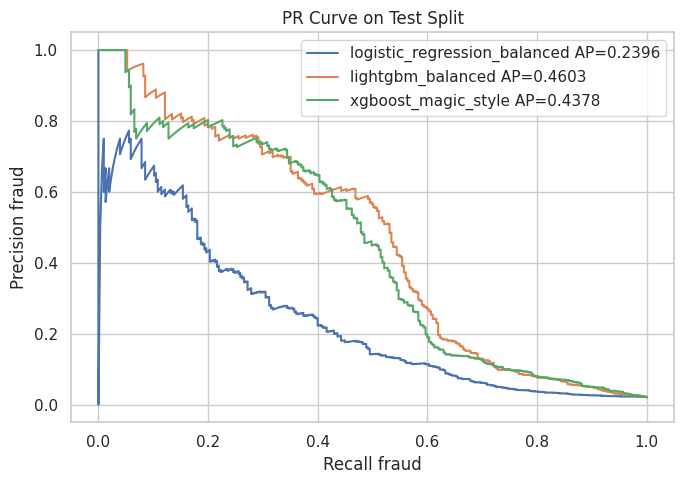

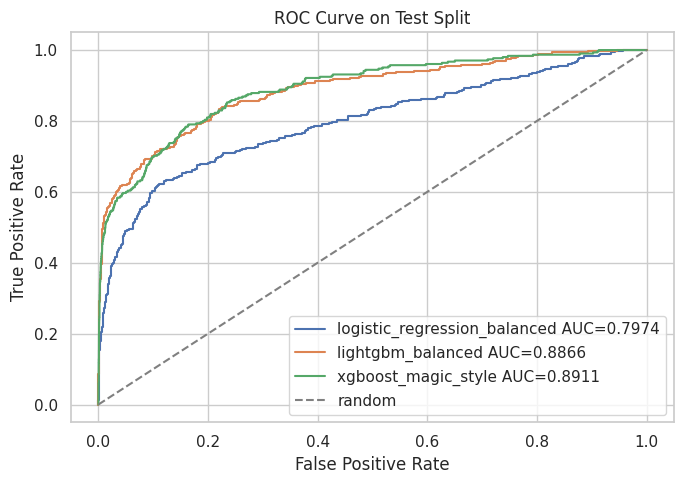

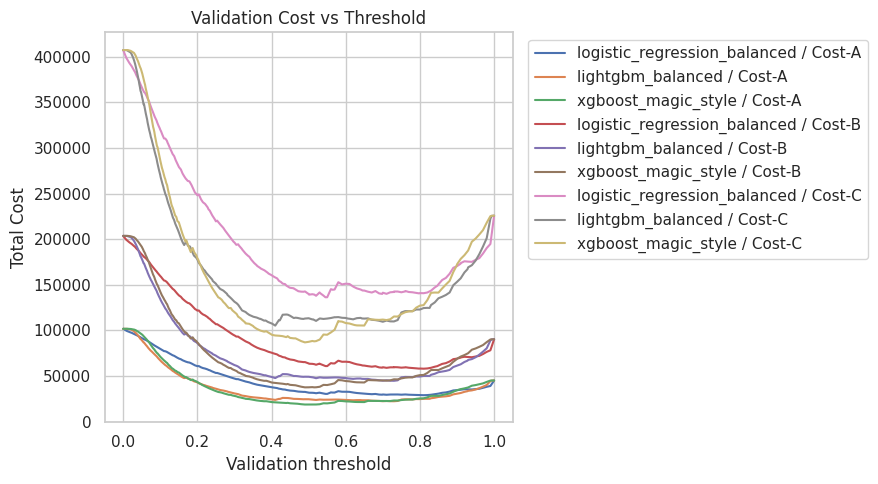

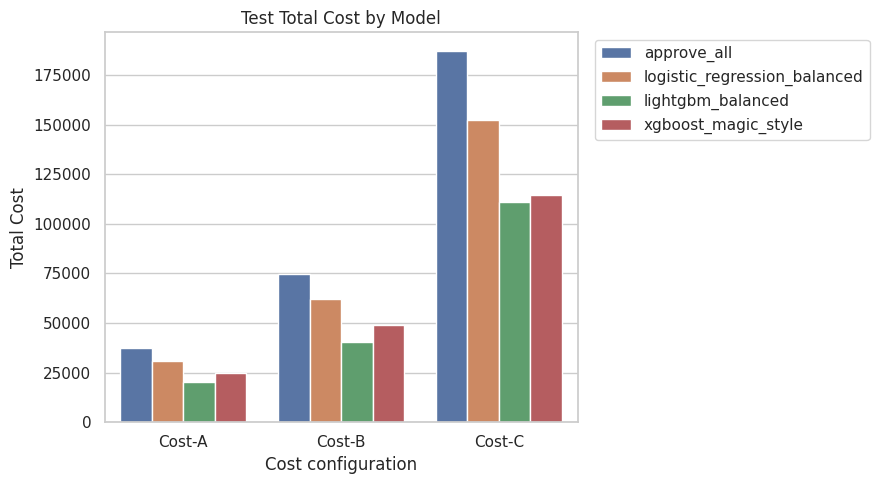

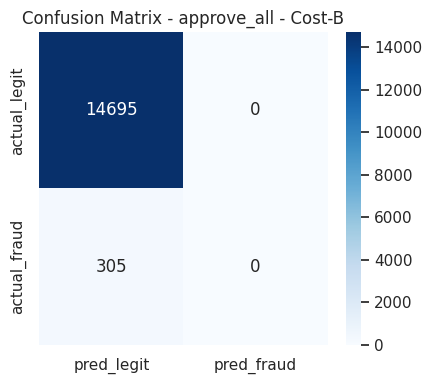

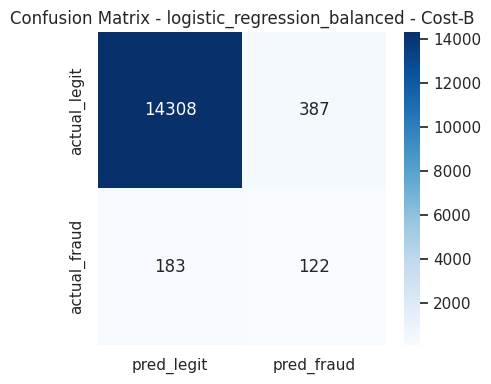

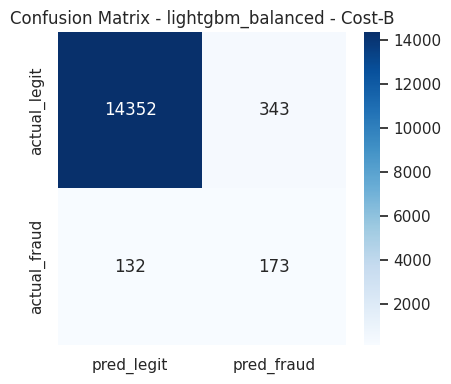

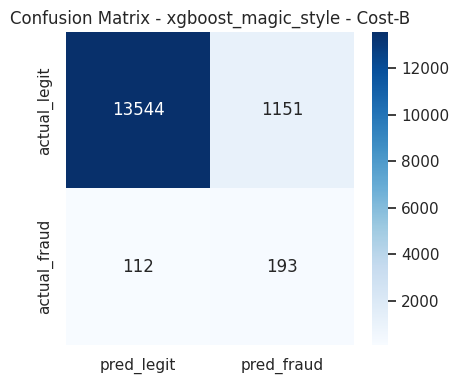

In [11]:
def save_current_figure(path):
    plt.tight_layout()
    plt.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()


trained_model_names = [name for name in model_scores if name != "approve_all"]

if trained_model_names:
    plt.figure(figsize=(7, 5))
    for model_name in trained_model_names:
        scores = model_scores[model_name]["test"]
        precision, recall, _ = precision_recall_curve(y_test, scores)
        ap = safe_average_precision(y_test, scores)
        plt.plot(recall, precision, label=f"{model_name} AP={ap:.4f}")
    plt.xlabel("Recall fraud")
    plt.ylabel("Precision fraud")
    plt.title("PR Curve on Test Split")
    plt.legend()
    save_current_figure(FIGURES_DIR / "pr_curve_baselines.png")

    plt.figure(figsize=(7, 5))
    for model_name in trained_model_names:
        scores = model_scores[model_name]["test"]
        if len(np.unique(y_test)) < 2:
            continue
        fpr, tpr, _ = roc_curve(y_test, scores)
        auc = safe_roc_auc(y_test, scores)
        plt.plot(fpr, tpr, label=f"{model_name} AUC={auc:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="random")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve on Test Split")
    plt.legend()
    save_current_figure(FIGURES_DIR / "roc_curve_baselines.png")

if not threshold_curve_df.empty:
    plt.figure(figsize=(9, 5))
    plot_df = threshold_curve_df.copy()
    plot_df["model_cost"] = plot_df["model"] + " / " + plot_df["cost_config"]
    sns.lineplot(data=plot_df, x="threshold", y="total_cost", hue="model_cost")
    plt.xlabel("Validation threshold")
    plt.ylabel("Total Cost")
    plt.title("Validation Cost vs Threshold")
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    save_current_figure(FIGURES_DIR / "cost_vs_threshold.png")

if not metrics_df.empty:
    test_metrics = metrics_df[metrics_df["split"] == "test"].copy()
    plt.figure(figsize=(9, 5))
    sns.barplot(data=test_metrics, x="cost_config", y="total_cost", hue="model")
    plt.xlabel("Cost configuration")
    plt.ylabel("Total Cost")
    plt.title("Test Total Cost by Model")
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    save_current_figure(FIGURES_DIR / "total_cost_by_model.png")

    # Save confusion matrices for the middle cost setting to avoid too many duplicate figures.
    matrix_cost_config = "Cost-B" if "Cost-B" in set(test_metrics["cost_config"]) else test_metrics["cost_config"].iloc[0]
    for _, row in test_metrics[test_metrics["cost_config"] == matrix_cost_config].iterrows():
        matrix = np.array([[row["tn"], row["fp"]], [row["fn"], row["tp"]]], dtype=int)
        plt.figure(figsize=(4.5, 4))
        sns.heatmap(
            matrix,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=["pred_legit", "pred_fraud"],
            yticklabels=["actual_legit", "actual_fraud"],
        )
        plt.title(f"Confusion Matrix - {row['model']} - {matrix_cost_config}")
        safe_model_name = str(row["model"]).replace("/", "_").replace(" ", "_")
        save_current_figure(FIGURES_DIR / f"confusion_matrix_{safe_model_name}_{matrix_cost_config}.png")

## 10. Phase 2 Conclusion

Bảng dưới đây xếp hạng kết quả test theo Total Cost. Khi viết báo cáo, ưu tiên PR-AUC, Recall/F1 fraud và chi phí FN/FP thay vì Accuracy, vì dữ liệu fraud rất mất cân bằng.

In [12]:
test_rank = metrics_df[metrics_df["split"] == "test"].sort_values(["cost_config", "total_cost"]).copy()
rank_columns = [
    "cost_config", "model", "threshold", "pr_auc", "roc_auc",
    "recall_fraud", "precision_fraud", "f1_fraud",
    "fn", "fp", "fn_cost", "fp_cost", "total_cost", "cost_saving_vs_approve_all",
]

display(test_rank[rank_columns])

best_by_cost = test_rank.groupby("cost_config", as_index=False).first()[[
    "cost_config", "model", "threshold", "total_cost", "cost_saving_vs_approve_all", "recall_fraud", "f1_fraud", "pr_auc"
]]
print("Best test model by cost configuration")
display(best_by_cost)

print("Notes for report:")
print("- Accuracy is not optimized because the fraud class is rare; high accuracy can still miss costly fraud cases.")
print("- Thresholds above were selected on validation only, then applied to test.")
print("- This notebook does not test LLM or RL, so it must not claim LLM/RL improvement.")
print("- Kaggle 1st place is treated as an external SOTA reference, not a directly comparable internal result unless fully reproduced under the same split/cost protocol.")
print("- The magic-style baseline uses train-only count/group statistics; it is inspired by Kaggle feature engineering but avoids leaderboard post-processing.")
print(f"Generated result files in: {RESULTS_DIR}")
print(f"Generated figure files in: {FIGURES_DIR}")

,cost_config,model,threshold,pr_auc,roc_auc,recall_fraud,precision_fraud,f1_fraud,fn,fp,fn_cost,fp_cost,total_cost,cost_saving_vs_approve_all
5,Cost-A,lightgbm_balanced,0.730000,0.460326,0.886567,0.567213,0.335271,0.421437,132,343,18039.317970,2159.069448,20198.387418,17244.647541
7,Cost-A,xgboost_magic_style,0.490000,0.437764,0.891059,0.632787,0.143601,0.234081,112,1151,16389.751976,8212.302143,24602.054119,12840.980840
3,Cost-A,logistic_regression_balanced,0.810000,0.239638,0.797354,0.400000,0.239686,0.299754,183,387,26982.424971,4041.330498,31023.755469,6419.279491
1,Cost-A,approve_all,NaN,0.020333,0.500000,0.000000,0.000000,0.000000,305,0,37443.034959,0.000000,37443.034959,0.000000
13,Cost-B,lightgbm_balanced,0.730000,0.460326,0.886567,0.567213,0.335271,0.421437,132,343,36078.635940,4318.138897,40396.774837,34489.295082
15,Cost-B,xgboost_magic_style,0.490000,0.437764,0.891059,0.632787,0.143601,0.234081,112,1151,32779.503953,16424.604285,49204.108238,25681.961680
11,Cost-B,logistic_regression_balanced,0.810000,0.239638,0.797354,0.400000,0.239686,0.299754,183,387,53964.849942,8082.660995,62047.510937,12838.558981
9,Cost-B,approve_all,NaN,0.020333,0.500000,0.000000,0.000000,0.000000,305,0,74886.069919,0.000000,74886.069919,0.000000
21,Cost-C,lightgbm_balanced,0.410000,0.460326,0.886567,0.737705,0.097784,0.172678,80,2076,51504.479876,59322.371937,110826.851813,76388.322984
23,Cost-C,xgboost_magic_style,0.490000,0.437764,0.891059,0.632787,0.143601,0.234081,112,1151,81948.759882,32849.208570,114797.968453,72417.206344


Best test model by cost configuration


,cost_config,model,threshold,total_cost,cost_saving_vs_approve_all,recall_fraud,f1_fraud,pr_auc
0,Cost-A,lightgbm_balanced,0.73,20198.387418,17244.647541,0.567213,0.421437,0.460326
1,Cost-B,lightgbm_balanced,0.73,40396.774837,34489.295082,0.567213,0.421437,0.460326
2,Cost-C,lightgbm_balanced,0.41,110826.851813,76388.322984,0.737705,0.172678,0.460326


Notes for report:
- Accuracy is not optimized because the fraud class is rare; high accuracy can still miss costly fraud cases.
- Thresholds above were selected on validation only, then applied to test.
- This notebook does not test LLM or RL, so it must not claim LLM/RL improvement.
- Kaggle 1st place is treated as an external SOTA reference, not a directly comparable internal result unless fully reproduced under the same split/cost protocol.
- The magic-style baseline uses train-only count/group statistics; it is inspired by Kaggle feature engineering but avoids leaderboard post-processing.
Generated result files in: /content/drive/MyDrive/BaoMatCuoiKy/LLM-Assisted_Cost-Sensitive/results
Generated figure files in: /content/drive/MyDrive/BaoMatCuoiKy/LLM-Assisted_Cost-Sensitive/reports/figures
